Import All Libraries

In [3]:
from google.colab import userdata
import os
import tensorflow as tf
import numpy as np
import gradio as gr
from keras.models import Sequential
from keras.layers import Activation
from keras.layers import Dense, Flatten ,GlobalAveragePooling2D,Dropout,BatchNormalization
from keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint,ReduceLROnPlateau

import keras.optimizers
from sklearn.metrics import classification_report
import keras.optimizers
from keras.applications import VGG16
from keras.applications.vgg16 import preprocess_input


from tensorflow.keras.preprocessing.image import ImageDataGenerator
from keras.src.applications.vgg16 import preprocess_input
# predict test image


from tensorflow.keras.preprocessing import image
import random
import matplotlib.pyplot as plt
import json
import seaborn as sns
from tensorflow.keras.optimizers import Adam, SGD

from sklearn.metrics import classification_report, confusion_matrix

from tensorflow.keras.models import Model, load_model
from tensorflow.keras.preprocessing.image import ImageDataGenerator, load_img, img_to_array
SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)
random.seed(SEED)

print(tf.__version__)

2.20.0


**KAGGLE INTEGRATION**

In [5]:
os.environ["KAGGLE_USERNAME"] = userdata.get("KAGGLE_USERNAME")
os.environ["KAGGLE_KEY"] = userdata.get("KAGGLE_KEY")

if os.environ["KAGGLE_USERNAME"] is None or os.environ["KAGGLE_KEY"] is None:
    raise ValueError("Please add KAGGLE_USERNAME and KAGGLE_KEY in Colab Secrets.")

print("Kaggle secrets loaded successfully.")

Kaggle secrets loaded successfully.


**DATASETS DOWNLOAD **

Brain Tumor MRI Dataset
https://www.kaggle.com/datasets/masoudnickparvar/brain-tumor-mri-dataset

In [6]:
!kaggle datasets download -d masoudnickparvar/brain-tumor-mri-dataset -p /content/data

Dataset URL: https://www.kaggle.com/datasets/masoudnickparvar/brain-tumor-mri-dataset
License(s): Attribution 4.0 International (CC BY 4.0)
100% 157M/157M [00:10<00:00, 15.9MB/s]



**UNZIP FOLDER OF DATASET**

In [7]:
import zipfile
import os

zip_path = "/content/data/brain-tumor-mri-dataset.zip"
extract_path = "/content/data"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Dataset extracted successfully.")

Dataset extracted successfully.


**DATA AUGMENTATION**

In [8]:

IMG_SIZE = 224
BATCH_SIZE = 32

train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    # rescale=1./255,
    rotation_range=15,
    zoom_range=0.15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True,
    fill_mode='nearest',
     validation_split=0.15
)

# Test generator: NO augmentation, only the same VGG16 preprocessing
test_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input
)

train_ds = train_datagen.flow_from_directory(
    "/content/data/Training",
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    subset="training",
    shuffle=True,
    seed=SEED
)

val_ds = train_datagen.flow_from_directory(
    "/content/data/Training",
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    subset="validation",
    shuffle=False,
    seed=SEED
)

# Held-out test set, completely separate from model selection
test_ds = test_datagen.flow_from_directory(
    "/content/data/Testing",
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    shuffle=False
)

Found 4760 images belonging to 4 classes.
Found 840 images belonging to 4 classes.
Found 1600 images belonging to 4 classes.


In [ ]:
print("Class indices:", train_ds.class_indices)

# Save the class index mapping so inference can NEVER get out of sync with training,
# even in a different session/notebook.
class_indices = train_ds.class_indices
idx_to_class = {v: k for k, v in class_indices.items()}

with open("/content/class_indices.json", "w") as f:
    json.dump(class_indices, f)

print(idx_to_class)

Class indices: {'glioma': 0, 'meningioma': 1, 'notumor': 2, 'pituitary': 3}
{0: 'glioma', 1: 'meningioma', 2: 'notumor', 3: 'pituitary'}


In [ ]:
print(train_ds.class_indices)

{'glioma': 0, 'meningioma': 1, 'notumor': 2, 'pituitary': 3}


**Stage 1 — Transfer learning (frozen VGG16 backbone)**
**FULLY CONNECTED LAYER AND OUTPUT LAYER**

---



In [ ]:

base_model = VGG16(
    weights='imagenet',
    include_top=False,
    input_shape=(224,224,3)
)

base_model.trainable = False

model = Sequential([
    base_model,

    GlobalAveragePooling2D(),

    BatchNormalization(),

    Dense(256, activation='relu'),

    Dropout(0.5),

    Dense(128, activation='relu'),

    Dropout(0.3),

    Dense(len(train_ds.class_indices), activation='softmax')
])




COMPILE MODEL

In [ ]:
model.compile(

    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ vgg16 (Functional)              │ (None, 7, 7, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_2      │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,881,476 (56.77 MB)

 Trainable params: 165,764 (647.52 KB)

 Non-trainable params: 14,715,712 (56.14 MB)

CALLBACKS

In [ ]:
early_stop = EarlyStopping(
    monitor="val_loss",
    patience=4,
    restore_best_weights=True
)

checkpoint = ModelCheckpoint(
    "/content/brain_tumor_mri_best.keras",
    monitor="val_loss",
    save_best_only=True
)

reduce_lr = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=2,
    min_lr=1e-7
)



FIT MODEL

In [ ]:
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=20,
    callbacks=[early_stop, checkpoint, reduce_lr]
)

Epoch 1/20
149/149 ━━━━━━━━━━━━━━━━━━━━ 117s 661ms/step - accuracy: 0.7109 - loss: 0.7534 - val_accuracy: 0.8548 - val_loss: 0.3913 - learning_rate: 0.0010
Epoch 2/20
149/149 ━━━━━━━━━━━━━━━━━━━━ 79s 527ms/step - accuracy: 0.8265 - loss: 0.4552 - val_accuracy: 0.8869 - val_loss: 0.3090 - learning_rate: 0.0010
Epoch 3/20
149/149 ━━━━━━━━━━━━━━━━━━━━ 78s 521ms/step - accuracy: 0.8542 - loss: 0.3847 - val_accuracy: 0.8988 - val_loss: 0.2874 - learning_rate: 0.0010
Epoch 4/20
149/149 ━━━━━━━━━━━━━━━━━━━━ 78s 527ms/step - accuracy: 0.8697 - loss: 0.3436 - val_accuracy: 0.9012 - val_loss: 0.2690 - learning_rate: 0.0010
Epoch 5/20
149/149 ━━━━━━━━━━━━━━━━━━━━ 83s 556ms/step - accuracy: 0.8838 - loss: 0.3162 - val_accuracy: 0.8976 - val_loss: 0.2737 - learning_rate: 0.0010
Epoch 6/20
149/149 ━━━━━━━━━━━━━━━━━━━━ 86s 580ms/step - accuracy: 0.8889 - loss: 0.2884 - val_accuracy: 0.9131 - val_loss: 0.2548 - learning_rate: 0.0010
Epoch 7/20
149/149 ━━━━━━━━━━━━━━━━━━━━ 79s 529ms/step - accuracy: 0.

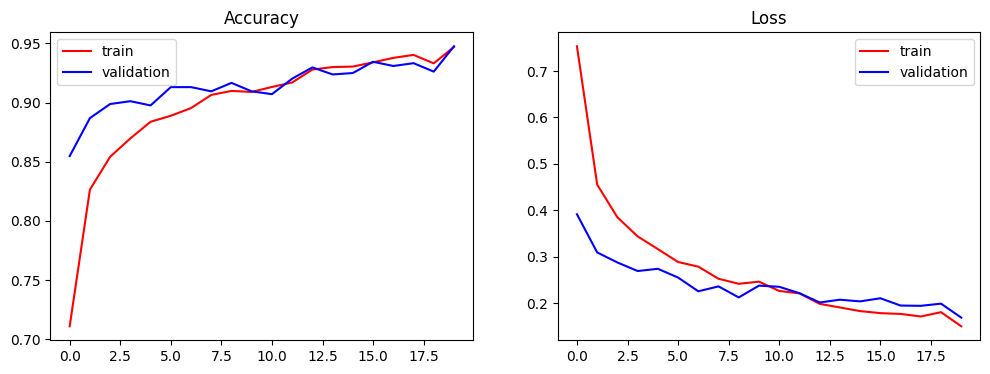

In [ ]:
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], color='red', label='train')
plt.plot(history.history['val_accuracy'], color='blue', label='validation')
plt.title('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], color='red', label='train')
plt.plot(history.history['val_loss'], color='blue', label='validation')
plt.title('Loss')
plt.legend()

plt.show()

In [ ]:
test_scores = model.evaluate(test_ds)
print('Test loss:', test_scores[0])
print('Test accuracy:', test_scores[1])

50/50 ━━━━━━━━━━━━━━━━━━━━ 9s 167ms/step - accuracy: 0.9013 - loss: 0.4762
Test loss: 0.4761767089366913
Test accuracy: 0.9012500047683716


50/50 ━━━━━━━━━━━━━━━━━━━━ 9s 170ms/step
              precision    recall  f1-score   support

      glioma       0.96      0.74      0.84       400
  meningioma       0.82      0.88      0.85       400
     notumor       0.91      0.99      0.95       400
   pituitary       0.92      0.99      0.96       400

    accuracy                           0.90      1600
   macro avg       0.91      0.90      0.90      1600
weighted avg       0.91      0.90      0.90      1600



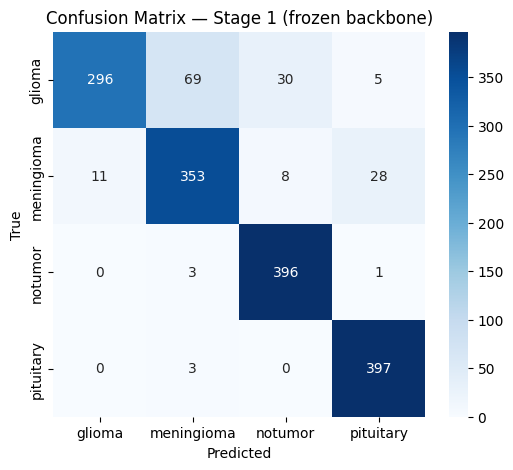

In [ ]:
y_pred_probs = model.predict(test_ds)
y_pred = np.argmax(y_pred_probs, axis=1)
y_true = test_ds.classes
class_names = list(test_ds.class_indices.keys())

print(classification_report(y_true, y_pred, target_names=class_names))

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix — Stage 1 (frozen backbone)')
plt.show()

**TEST RANDOM IMAGE**

Class: notumor
Image: /content/data/Testing/notumor/Te-no_231.jpg


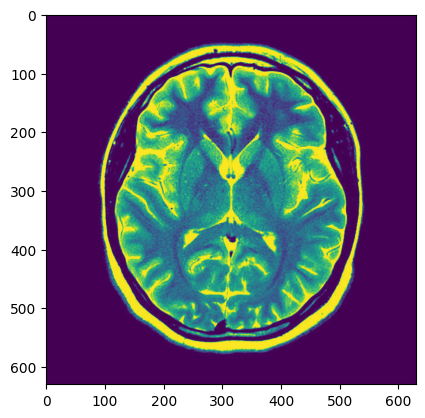

In [ ]:
import os
import random

test_dir = "/content/data/Testing"

class_name = random.choice(os.listdir(test_dir))
img_name = random.choice(os.listdir(os.path.join(test_dir, class_name)))

img_path = os.path.join(test_dir, class_name, img_name)

print("Class:", class_name)
print("Image:", img_path)

plt.imshow(plt.imread(img_path))
plt.show()

**Stage 2 — Fine-tuning (unfreeze the last VGG16 block)**

In [ ]:
# Unfreeze from block5 onward (last conv block), keep blocks 1-4 frozen
base_model.trainable = True
fine_tune_at = 15  # layer index where block5 starts

for layer in base_model.layers[:fine_tune_at]:
    layer.trainable = False
for layer in base_model.layers[fine_tune_at:]:
    layer.trainable = True

model.compile(
    optimizer=SGD(learning_rate=1e-5, momentum=0.9),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ vgg16 (Functional)              │ (None, 7, 7, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_2      │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,881,476 (56.77 MB)

 Trainable params: 7,245,188 (27.64 MB)

 Non-trainable params: 7,636,288 (29.13 MB)

In [ ]:
ft_early_stop = EarlyStopping(
    monitor="val_loss",
    patience=4,
    restore_best_weights=True
)

ft_checkpoint = ModelCheckpoint(
    "/content/brain_tumor_mri_finetuned_best.keras",
    monitor="val_loss",
    save_best_only=True
)

ft_reduce_lr = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=2,
    min_lr=1e-8
)

fine_tune_history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=15,
    callbacks=[ft_early_stop, ft_checkpoint, ft_reduce_lr]
)

Epoch 1/15
149/149 ━━━━━━━━━━━━━━━━━━━━ 94s 583ms/step - accuracy: 0.9443 - loss: 0.1548 - val_accuracy: 0.9321 - val_loss: 0.1885 - learning_rate: 1.0000e-05
Epoch 2/15
149/149 ━━━━━━━━━━━━━━━━━━━━ 82s 549ms/step - accuracy: 0.9458 - loss: 0.1513 - val_accuracy: 0.9333 - val_loss: 0.1713 - learning_rate: 1.0000e-05
Epoch 3/15
149/149 ━━━━━━━━━━━━━━━━━━━━ 89s 597ms/step - accuracy: 0.9492 - loss: 0.1465 - val_accuracy: 0.9417 - val_loss: 0.1810 - learning_rate: 1.0000e-05
Epoch 4/15
149/149 ━━━━━━━━━━━━━━━━━━━━ 80s 540ms/step - accuracy: 0.9445 - loss: 0.1513 - val_accuracy: 0.9417 - val_loss: 0.1613 - learning_rate: 1.0000e-05
Epoch 5/15
149/149 ━━━━━━━━━━━━━━━━━━━━ 81s 543ms/step - accuracy: 0.9500 - loss: 0.1292 - val_accuracy: 0.9369 - val_loss: 0.1665 - learning_rate: 1.0000e-05
Epoch 6/15
149/149 ━━━━━━━━━━━━━━━━━━━━ 80s 538ms/step - accuracy: 0.9500 - loss: 0.1328 - val_accuracy: 0.9369 - val_loss: 0.1498 - learning_rate: 1.0000e-05
Epoch 7/15
149/149 ━━━━━━━━━━━━━━━━━━━━ 79s 53

50/50 ━━━━━━━━━━━━━━━━━━━━ 8s 167ms/step - accuracy: 0.9013 - loss: 0.4827
Test loss: 0.48268717527389526
Test accuracy: 0.9012500047683716
50/50 ━━━━━━━━━━━━━━━━━━━━ 10s 182ms/step
              precision    recall  f1-score   support

      glioma       0.96      0.74      0.84       400
  meningioma       0.82      0.88      0.85       400
     notumor       0.91      0.99      0.95       400
   pituitary       0.93      0.99      0.96       400

    accuracy                           0.90      1600
   macro avg       0.91      0.90      0.90      1600
weighted avg       0.91      0.90      0.90      1600



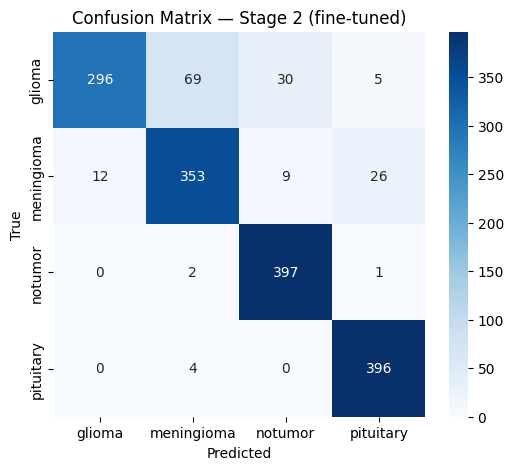

In [ ]:
test_scores = model.evaluate(test_ds)
print('Test loss:', test_scores[0])
print('Test accuracy:', test_scores[1])

y_pred_probs = model.predict(test_ds)
y_pred = np.argmax(y_pred_probs, axis=1)
y_true = test_ds.classes

print(classification_report(y_true, y_pred, target_names=class_names))

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix — Stage 2 (fine-tuned)')
plt.show()

In [ ]:
model.save("/content/brain_tumor_mri_final.keras")

# Keep the class mapping right next to the model so they can never drift apart
# with open("/content/class_indices.json", "w") as f:
#     json.dump(train_ds.class_indices, f)

print("Final model and class_indices.json saved successfully.")

Final model and class_indices.json saved successfully.


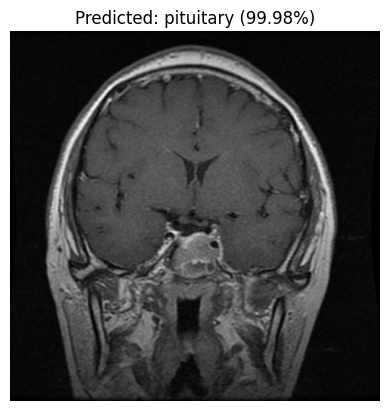

Predicted Class: [1.5563121e-06 2.3560111e-04 1.0511126e-05 9.9975234e-01]
Confidence: 99.98%


{'glioma': 1.55631209963758e-06,
 'meningioma': 0.00023560111003462225,
 'notumor': 1.0511125765333418e-05,
 'pituitary': 0.9997523427009583}

In [50]:
model=load_model('/content/brain_tumor_mri_final.keras')
class_names = ['glioma', 'meningioma', 'notumor', 'pituitary']
img_size=224

def predict_image(img_path):
    """Predict the tumor class for a single image file, robust to RGBA/grayscale input."""
    # color_mode='rgb' forces 3 channels even if the source file is grayscale/RGBA/CMYK


    img = load_img(img_path, target_size=(img_size, img_size), color_mode='rgb')
    img_array = img_to_array(img)
    img_array = np.expand_dims(img_array, axis=0)

    # Use the SAME preprocessing as training -- this is critical for correct predictions
    img_array = preprocess_input(img_array)

    prediction = model.predict(img_array,verbose=0)[0]
    predicted_class = class_names[np.argmax(prediction)]
    confidence = float(np.max(prediction))


    plt.imshow(load_img(img_path))
    plt.axis('off')
    plt.title(f"Predicted: {predicted_class} ({confidence * 100:.2f}%)")
    plt.show()

    print(f"Predicted Class: {prediction}")
    print(f"Confidence: {confidence * 100:.2f}%")
    return {
        # predicted_class:confidence
    class_names[i]: float(prediction[i])
    for i in range(len(class_names))
    }


test_dir = "/content/data/Testing"
class_name = random.choice(os.listdir(test_dir))
img_name = random.choice(os.listdir(os.path.join(test_dir, class_name)))
img_path = os.path.join(test_dir, class_name, img_name)

# call method pass model path
predict_image(img_path)

Saving nutmor.png to nutmor.png


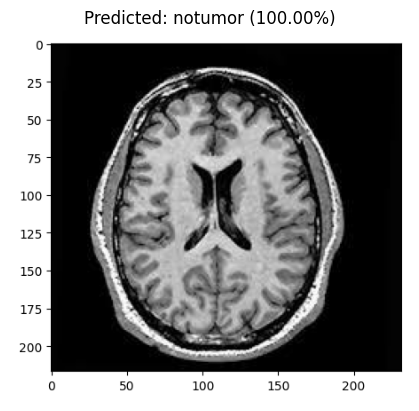

Predicted Class: [4.8885073e-11 5.1576438e-07 9.9999952e-01 2.8561209e-12]
Confidence: 100.00%


{'glioma': 4.888507307287959e-11,
 'meningioma': 5.157643840902892e-07,
 'notumor': 0.9999995231628418,
 'pituitary': 2.8561209387129027e-12}

In [51]:
from google.colab import files

uploaded = files.upload()
uploaded_image_path = list(uploaded.keys())[0]

predict_image(uploaded_image_path)

**Gradio Interface**

In [26]:
!pip install -q gradio tensorflow pillow reportlab


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 69.2 MB/s eta 0:00:00


In [34]:
from reportlab.platypus import (
    SimpleDocTemplate,
    Paragraph,
    Spacer,
    Table,
    TableStyle
)

from reportlab.lib import colors
from reportlab.lib.styles import getSampleStyleSheet
from reportlab.lib.pagesizes import letter
from reportlab.platypus.flowables import HRFlowable
from datetime import datetime


def create_report_mri(predicted_class, confidence):

    pdf_path = "mri_report.pdf"

    doc = SimpleDocTemplate(
        pdf_path,
        pagesize=letter,
        rightMargin=40,
        leftMargin=40,
        topMargin=40,
        bottomMargin=30
    )

    styles = getSampleStyleSheet()
    elements = []

    # ===== Title =====
    title = Paragraph(
        "<font size=22 color='darkblue'><b>Brain MRI Analysis Report</b></font>",
        styles['Title']
    )

    elements.append(title)
    elements.append(Spacer(1, 12))

    # ===== Line =====
    elements.append(HRFlowable(width="100%", color=colors.darkblue))
    elements.append(Spacer(1, 20))

    # ===== Date =====
    date_text = datetime.now().strftime("%d-%m-%Y %H:%M:%S")

    date_para = Paragraph(
        f"<b>Generated On:</b> {date_text}",
        styles['Normal']
    )

    elements.append(date_para)
    elements.append(Spacer(1, 20))

    # ===== Prediction Result =====
    result_title = Paragraph(
        "<font size=16 color='green'><b>Prediction Result</b></font>",
        styles['Heading2']
    )

    elements.append(result_title)
    elements.append(Spacer(1, 10))

    # ===== Table =====
    data = [
        ["Parameter", "Value"],
        ["Predicted Tumor Type", predicted_class.upper()],
        ["Confidence Score", f"{confidence * 100:.2f}%"]
    ]

    table = Table(data, colWidths=[220, 220])

    table.setStyle(TableStyle([
        ('BACKGROUND', (0, 0), (-1, 0), colors.darkblue),
        ('TEXTCOLOR', (0, 0), (-1, 0), colors.white),

        ('BACKGROUND', (0, 1), (-1, -1), colors.whitesmoke),

        ('GRID', (0, 0), (-1, -1), 1, colors.black),

        ('FONTNAME', (0, 0), (-1, 0), 'Helvetica-Bold'),

        ('FONTNAME', (0, 1), (-1, -1), 'Helvetica'),

        ('BOTTOMPADDING', (0, 0), (-1, 0), 12),

        ('BACKGROUND', (0, 1), (-1, 1), colors.lightblue),

        ('BACKGROUND', (0, 2), (-1, 2), colors.beige),
    ]))

    elements.append(table)
    elements.append(Spacer(1, 25))

    # ===== Recommendation =====
    recommendation = Paragraph(
        """
        <font size=12>
        <b>Medical Note:</b><br/>
        This AI-generated report is intended for research and educational purposes only.
        Please consult a certified radiologist or neurologist for professional diagnosis.
        </font>
        """,
        styles['BodyText']
    )

    elements.append(recommendation)
    elements.append(Spacer(1, 20))

    # ===== Footer =====
    footer = Paragraph(
        "<font color='grey'>Generated using Deep Learning VGG16 MRI Classification System</font>",
        styles['Italic']
    )

    elements.append(footer)

    # Build PDF
    doc.build(elements)

    return pdf_path

In [48]:
model=load_model('/content/brain_tumor_mri_final.keras')
class_names = ['glioma', 'meningioma', 'notumor', 'pituitary']
IMG_SIZE=224

def predict_image(img_path):
  """Predict the tumor class for a single image file, robust to RGBA/grayscale input."""
  # # Convert to RGB
  image = img_path.convert("RGB")
  # Resize
  image = image.resize((IMG_SIZE, IMG_SIZE))
  img_array = img_to_array(image)
  img_array = np.expand_dims(img_array, axis=0)

  # Use the SAME preprocessing as training -- this is critical for correct predictions
  img_array = preprocess_input(img_array)
  prediction = model.predict(img_array,verbose=0)[0]
  predicted_class = class_names[np.argmax(prediction)]
  confidence = float(np.max(prediction))

  # MRI REPORT
  report=create_report_mri(predicted_class,confidence)
  return ({
        predicted_class:confidence
    # class_names[i]: float(prediction[i])
    # for i in range(len(class_names))
    }, report)


interface = gr.Interface(
    fn=predict_image,
    inputs=gr.Image(type="pil"),
    outputs=[
        gr.Label(num_top_classes=4),
        gr.File(label="Download Report")
    ],
    title="Brain Tumor Classification",
    description="Classify MRI images into Glioma, Meningioma, Pituitary, or No Tumor using VGG16 Transfer Learning.",

)

interface.launch()

It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://0923d58ac17b0852b2.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
